# Customer Segmentation Day 26 Dibimbing

## Data loading

In [1]:
import pandas as pd
import numpy as np
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
print(openpyxl.__version__)

3.1.5


In [3]:
df = pd.read_excel(r"C:\Users\Admin\Documents\dibimbing\Dibimbing---DSDA\Assignment Day 26 -  Customer Segmentation\superstore_dataset.xlsx")
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,subcategory,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
data = df.copy()

## EDA 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null   object        
 15  subcategory    9994 n

In [6]:
df.describe()

,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355392,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [7]:
df.isnull().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
subcategory      0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
for col in data.columns:
    print(f"{col}: {df[col].nunique()} unique values")

row_id: 9994 unique values
order_id: 5009 unique values
order_date: 1237 unique values
ship_date: 1334 unique values
ship_mode: 4 unique values
customer_id: 793 unique values
customer_name: 793 unique values
segment: 3 unique values
country: 1 unique values
city: 531 unique values
state: 49 unique values
postal_code: 631 unique values
region: 4 unique values
product_id: 1862 unique values
category: 3 unique values
subcategory: 17 unique values
product_name: 1850 unique values
sales: 5825 unique values
quantity: 14 unique values
discount: 12 unique values
profit: 7287 unique values


### Data Cleaning

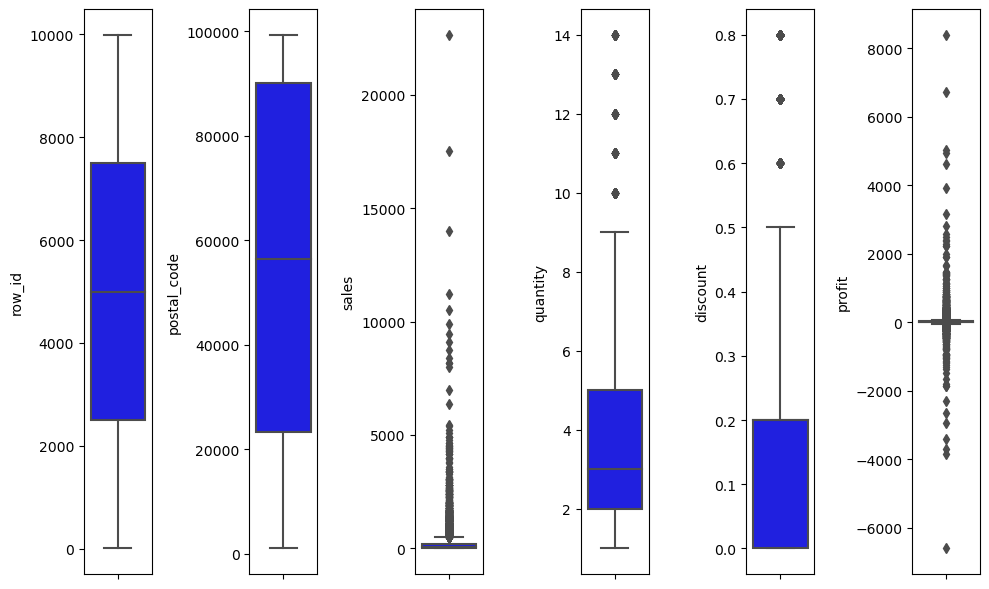

In [10]:
# Check outliers
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
for i in range(0, len(numerical_columns)):
    plt.subplot(1,len(numerical_columns), i+1)
    sns.boxplot(y=data[numerical_columns[i]], color='blue')
    plt.tight_layout()

Sales and Profit has a wide range of outliers. But need to check if this makes any sense.

In [11]:
df[['sales', 'profit']].sort_values(by='sales', ascending=False).head(10)

,sales,profit
2702,22638.480,-1811.0784
6830,17499.950,8399.9760
8153,13999.960,6719.9808
2629,11199.968,3919.9888
4196,10499.970,5039.9856
9040,9892.740,4946.3700
4104,9449.950,4630.4755
4283,9099.930,2365.9818
8488,8749.950,2799.9840
6429,8399.976,1119.9968


In [12]:
df[['sales', 'profit']].sort_values(by='profit', ascending=False).head(10)

,sales,profit
6830,17499.950,8399.9760
8153,13999.960,6719.9808
4196,10499.970,5039.9856
9040,9892.740,4946.3700
4104,9449.950,4630.4755
2629,11199.968,3919.9888
510,6354.950,3177.4750
8488,8749.950,2799.9840
7670,5399.910,2591.9568
6524,5443.960,2504.2216


In [13]:
# Check the category of that transaction
df.loc[df['sales'] == 22638.48][['category', 'subcategory', 'product_name','discount', 'sales', 'profit']]

,category,subcategory,product_name,discount,sales,profit
2702,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,0.5,22638.48,-1811.0784


The outliers is makes sense, since there is an effect of discount, some products might have a very less or a loss selling the products, since the data does not have a cost table we can add it on PBI.

In [31]:
df.groupby('customer_id')['sales'].sum().sort_values(ascending=False).head()
df.groupby('customer_id')['order_id'].nunique().sort_values(ascending=False).head()

customer_id
EP-13915    17
ZC-21910    13
CK-12205    13
SH-19975    13
JE-15745    13
Name: order_id, dtype: int64

<Axes: ylabel='region'>

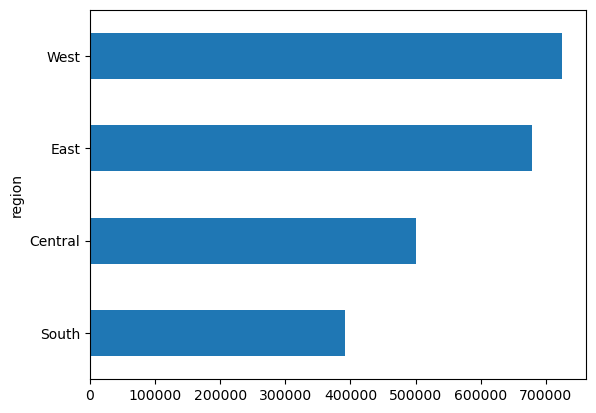

In [ ]:
df.groupby('region')['sales'].sum().sort_values().plot(kind='barh')

<Axes: xlabel='category'>

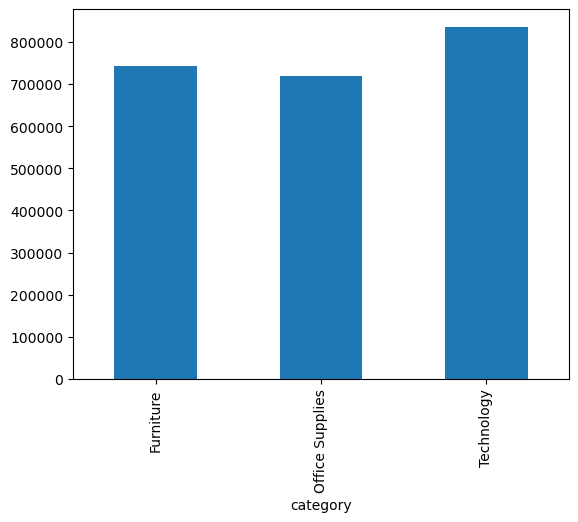

In [38]:
df.groupby('category')['sales'].sum().plot(kind='bar')

<Axes: xlabel='segment'>

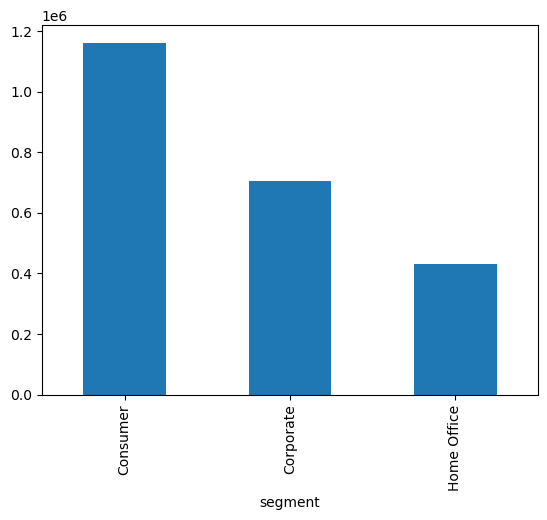

In [39]:
df.groupby('segment')['sales'].sum().plot(kind='bar')

c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Admin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='sales', ylabel='Count'>

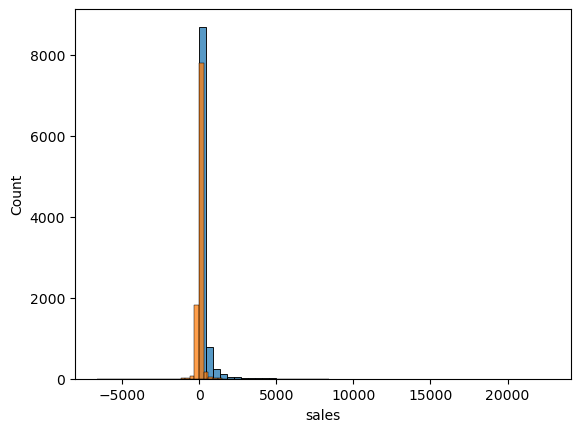

In [40]:
import seaborn as sns
sns.histplot(df['sales'], bins=50)
sns.histplot(df['profit'], bins=50)
